In [1]:
"""
Test strategies based on simple technical indicators (RSI, MA, MACD, Bollinger etc.) on
    - random processes with length of 1000 candles for example 
    - (preferred) (if we think the trading process is not really random walk) on data from different major pairs. Start on dirrefent date within last year
    
How to simulate volume? Volume is not random and have clusters which coresponds to the valotility.. 

Get statistics (run many many times) and measure when in average (in how many candles) the strategy will give the certain profit (0, 10%, 50%)

Will it converge or diverge? 

Question: will we have the different average periods or the same?
If the same - which period will it be.
Can we measure the average speed

What is the properties of random process? Can I measure some properties from stock prices and apply them to the random process to get a 
random_process' with the standats deviations not higher than the measured ones. And then test strategies on that random_process'

"""

"\nTest strategies based on simple technical indicators (RSI, MA, MACD, Bollinger etc.) on\n    - random processes with length of 1000 candles for example \n    - (preferred) (if we think the trading process is not really random walk) on data from different major pairs. Start on dirrefent date within last year\n    \nHow to simulate volume? Volume is not random and have clusters which coresponds to the valotility.. \n\nGet statistics (run many many times) and measure when in average (in how many candles) the strategy will give the certain profit (0, 10%, 50%)\n\nWill it converge or diverge? \n\nQuestion: will we have the different average periods or the same?\nIf the same - which period will it be.\nCan we measure the average speed\n\nWhat is the properties of random process? Can I measure some properties from stock prices and apply them to the random process to get a \nrandom_process' with the standats deviations not higher than the measured ones. And then test strategies on that rand

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import ccxt
import math
import datetime
import os
import concurrent.futures
import multiprocessing as mp
import traceback

In [2]:
pairs = ["GMX/USDT", 
"BCH/USDT", 
"ETC/USDT", 
"HBAR/USDT", 
"ILV/USDT", 
"TRB/USDT", 
"ETH/USDT", 
"ADA/USDT", 
"NEO/USDT", 
"SAND/USDT", 
"TON/USDT", 
"RUNE/USDT", 
"FIL/USDT", 
"NEAR/USDT", 
"MKR/USDT", 
"LINK/USDT", 
"ATOM/USDT", 
"BSV/USDT", 
"UNI/USDT", 
"LTC/USDT", 
"AAVE/USDT", 
"COMP/USDT", 
"SUSHI/USDT", 
"ZRO/USDT", 
"SOL/USDT", 
"CRV/USDT", 
"BTC/USDT"]
timeframe = "5m"

if timeframe[-1] != "m":
    raise ValueError('timeframe[-1] != "m"')

tf_milliseconds = int(timeframe[:-1]) * 60000

In [3]:
exchange = ccxt.binance()

In [4]:
p_data = {}
limit=1000
# since = exchange.milliseconds () - 86400000  # -1 day from now
since = exchange.milliseconds () - (tf_milliseconds * limit)
for pair in pairs:
    ohlcv = exchange.fetch_ohlcv(pair, timeframe, since=since, limit=limit)
    p_data[pair] = pd.DataFrame(ohlcv, columns=["TIME", "OPEN", "HIGH", "LOW", "CLOSE", "VOLUME"])
    p_data[pair]["TIME"] = pd.to_datetime(p_data[pair]["TIME"], unit="ms")
print("max: ", p_data[pairs[0]].max(axis=0)['TIME'])
print("min: ", p_data[pairs[0]].min(axis=0)['TIME'])

max:  2025-03-01 15:40:00
min:  2025-02-26 04:25:00


In [5]:
"""
get DataFrame with correlations depending on the window from earliest to oldest
"""
pairs_lim = list(p_data.keys())#[:1]
out_pair = {pair: pd.DataFrame(columns=['corr(O-C->V)', 'corr(H-L->V)', 'corr(O-C->H-L)', 'std(O-C)', 'std(H-L)']) for pair in pairs_lim}
for i in range(10, limit):
    for pair in pairs_lim:
        df_orig = p_data[pair].drop('TIME', axis=1).tail(i) # newest are in the tail
        
        # normalize by columns
        df = pd.DataFrame(columns=df_orig.columns.to_list())
        for c in df_orig:
            # minmax
            # df[c]=(df_orig[c] - df_orig[c].mean()) / (df_orig[c].max() - df_orig[c].min())
            # Z-normalization
            df[c]=(df_orig[c] - df_orig[c].mean()) / df_orig[c].std()

        df["OPEN-CLOSE"] = abs(df['OPEN'] - df['CLOSE'])
        df["HIGH-LOW"] = abs(df['HIGH'] - df['LOW'])
        corr = df.corr().drop(["OPEN", "HIGH", "LOW", "CLOSE", "VOLUME"], axis=1)
        out_pair[pair].loc[i] = [corr['OPEN-CLOSE']['VOLUME'], corr['HIGH-LOW']['VOLUME'], corr['OPEN-CLOSE']['HIGH-LOW'], df["OPEN-CLOSE"].std(), df["HIGH-LOW"].std()]

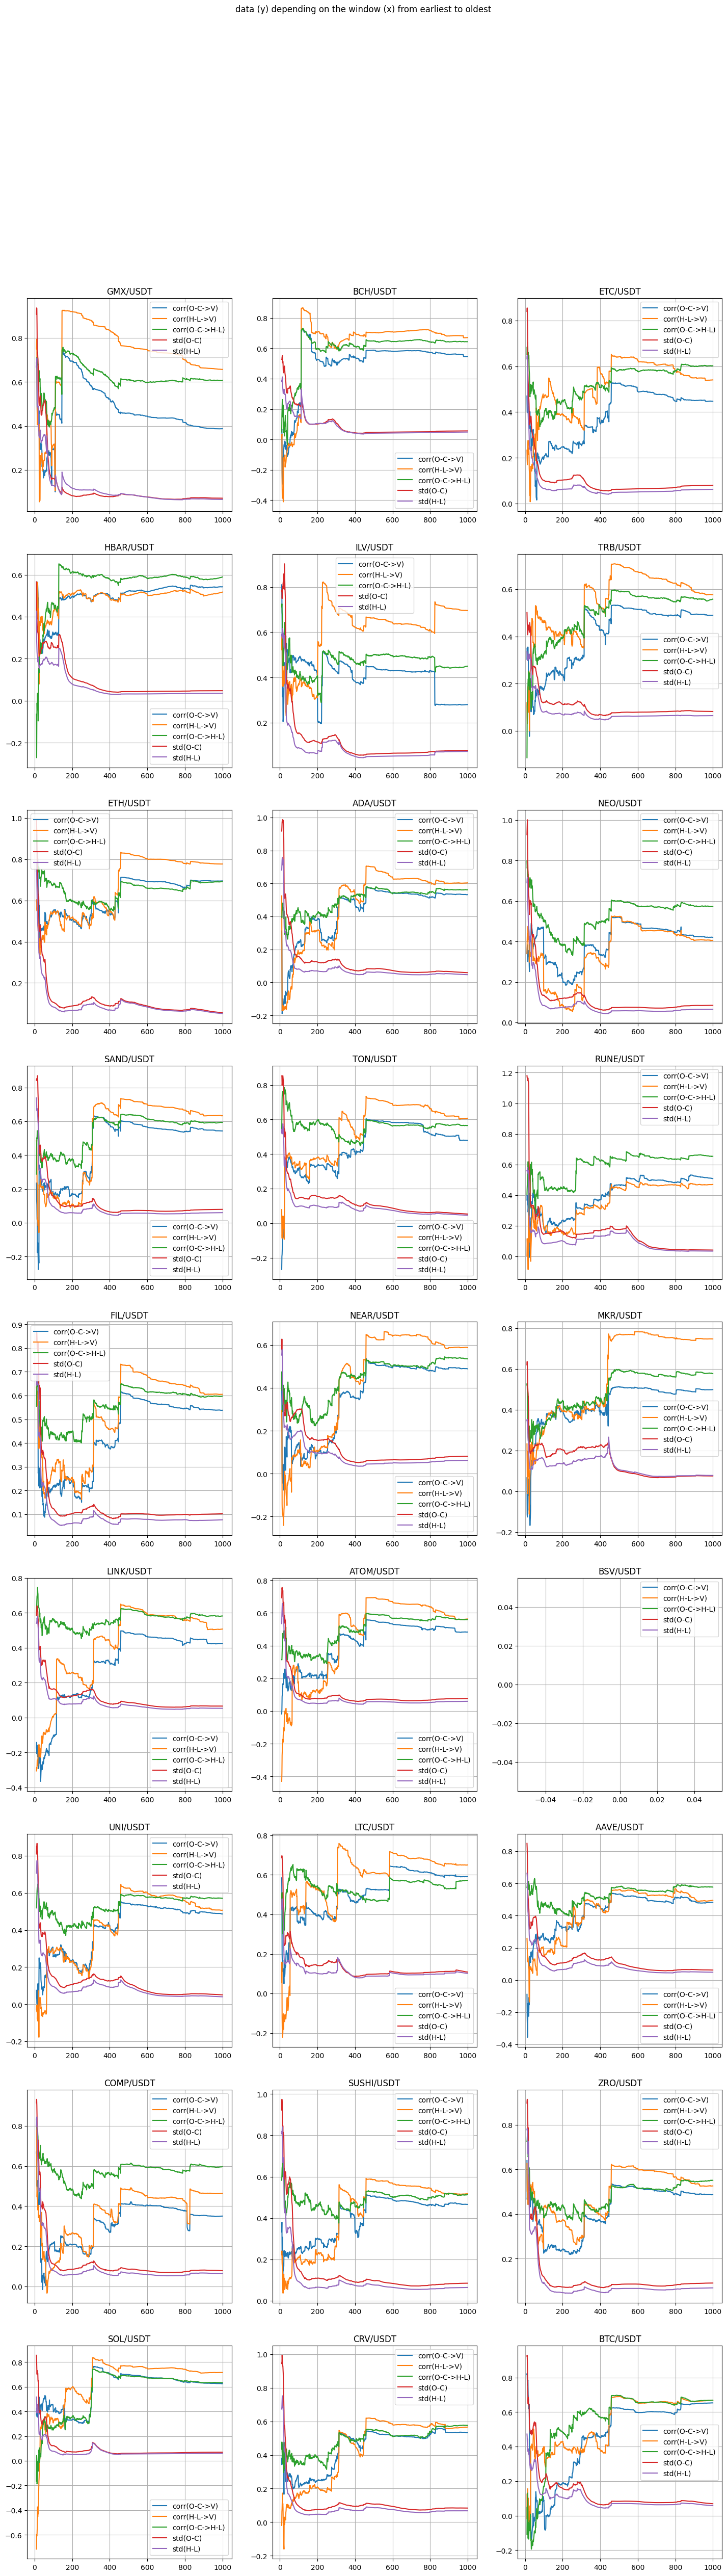

In [6]:
"""
visualize
"""
pairs_lim = list(p_data.keys())#[:1]

# (rows, columns)
layout = [math.ceil(len(pairs_lim) / 3), 3]
fig, axes = plt.subplots(nrows=layout[0], ncols=layout[1])#, width_ratios=2, height_ratios=2)
fig.set_size_inches(w=1760/100, h=layout[0]*640/100)
fig.suptitle('data (y) depending on the window (x) from earliest to oldest')
axe = axes.ravel()
for pair, ax in zip(pairs_lim, axe):
    out_pair[pair].plot(kind='line', title=pair, ax=ax, grid=True)
# plt.show()
plt.savefig('10_to_1000_newest_to_oldest.pdf')


In [4]:
"""
Analyze 'n_periods' periods
Get 'limit' candles from different, consequent, not overlaping period of time in the past starting from earliest
For each period calculate 'corr(O-C->V)', 'corr(H-L->V)', 'corr(O-C->H-L)', 'std(O-C)', 'std(H-L)'
"""
n_periods = 10
limit = 50

pairs_lim = pairs#[:1]

def one(pair, period, timeframe, limit, exchange):

    if timeframe[-1] != "m":
        raise ValueError('timeframe[-1] != "m"')
    tf_milliseconds = int(timeframe[:-1]) * 60000
    # since = exchange.milliseconds () - 86400000  # -1 day from now
    since = exchange.milliseconds () - (tf_milliseconds * limit * period)
    ohlcv = exchange.fetch_ohlcv(pair, timeframe, since=since, limit=limit)
    df_orig = pd.DataFrame(ohlcv, columns=["TIME", "OPEN", "HIGH", "LOW", "CLOSE", "VOLUME"]).drop('TIME', axis=1)
    
    # normalize by columns
    df = pd.DataFrame(columns=df_orig.columns.to_list())
    for c in df_orig:
        # minmax
        # df[c]=(df_orig[c] - df_orig[c].mean()) / (df_orig[c].max() - df_orig[c].min())
        # Z-normalization
        df[c]=(df_orig[c] - df_orig[c].mean()) / df_orig[c].std()

    df["OPEN-CLOSE"] = abs(df['OPEN'] - df['CLOSE'])
    df["HIGH-LOW"] = abs(df['HIGH'] - df['LOW'])
    corr = df.corr().drop(["OPEN", "HIGH", "LOW", "CLOSE", "VOLUME"], axis=1)
    lst = [corr['OPEN-CLOSE']['VOLUME'], corr['HIGH-LOW']['VOLUME'], corr['OPEN-CLOSE']['HIGH-LOW'], df["OPEN-CLOSE"].std(), df["HIGH-LOW"].std()]

    return lst

out_pair_1 = {pair: pd.DataFrame(columns=['corr(O-C->V)', 'corr(H-L->V)', 'corr(O-C->H-L)', 'std(O-C)', 'std(H-L)']) for pair in pairs_lim}
for pair in pairs_lim:
    for period in range(1, n_periods+1): # period = from 1 to n_periods
        lst = one(pair, period, timeframe, limit, exchange)
        out_pair_1[pair].loc[period] = lst


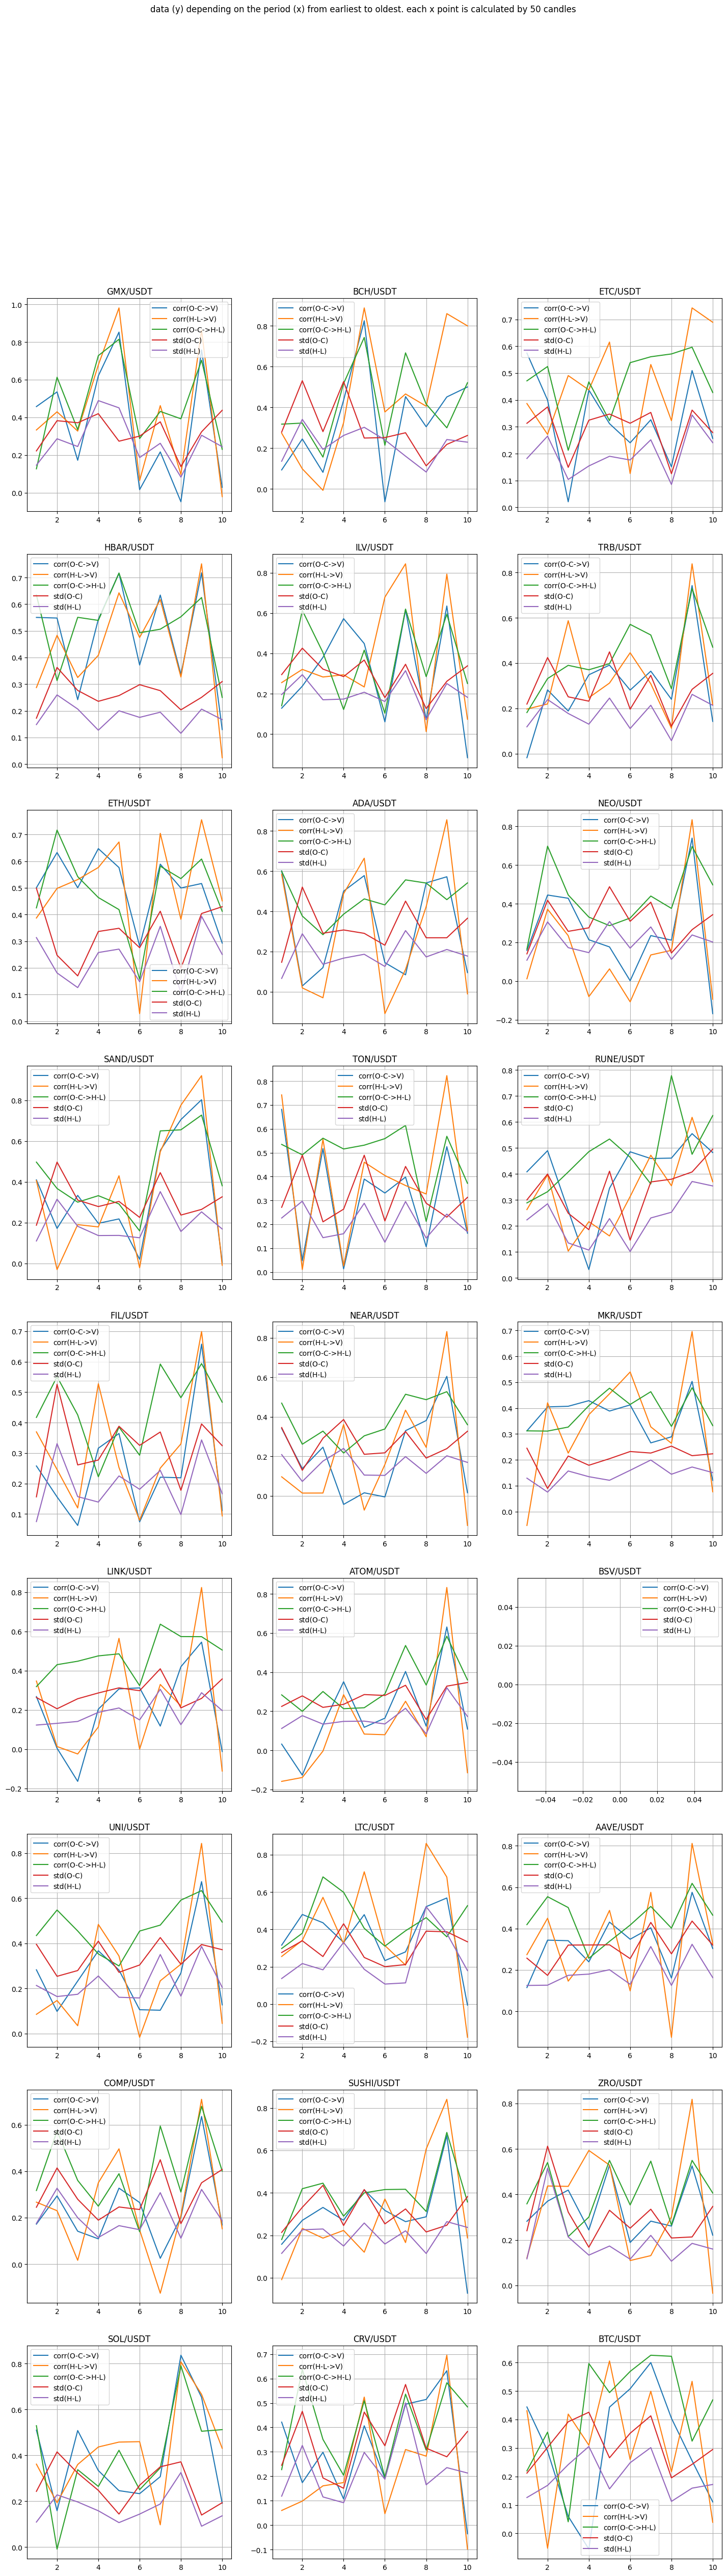

In [5]:
"""
visualize
"""
pairs_lim = list(out_pair_1.keys())
# (rows, columns)
layout = [math.ceil(len(pairs_lim) / 3), 3]
fig, axes = plt.subplots(nrows=layout[0], ncols=layout[1])#, width_ratios=2, height_ratios=2)
fig.set_size_inches(w=1760/100, h=layout[0]*640/100)
fig.suptitle(f'data (y) depending on the period (x) from earliest to oldest. each x point is calculated by {limit} candles')
axe = axes.ravel()
for pair, ax in zip(pairs_lim, axe):
    out_pair_1[pair].plot(kind='line', title=pair, ax=ax, grid=True)
# plt.show()
plt.savefig(f'p_{n_periods}_lim_{limit}_newest_to_oldest.pdf')